# SO Fisher constraint analysis

This notebook analyzes the completed Fisher products in this directory for SO baseline and goal noise, each with conditional-noise and Gaussian-total covariance.

**Important:** every data Fisher matrix has rank 6/9. A data-only nine-parameter marginalized covariance is singular. Full marginalized contours therefore use the saved prior-regularized covariance and are labeled accordingly.

In [1]:
import sys
import site

print("Python:", sys.executable)
print("User site:", site.getusersitepackages())
print("\n".join(sys.path))

Python: /home/cbllover/miniconda3/envs/halfdome/bin/python
User site: /home/kn18001/.local/lib/python3.11/site-packages
/home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis
/home/cbllover/CosmoBolognaLib_pub/Python
/home/kn18001/illustris_python
/home/cbllover/miniconda3/envs/halfdome/lib/python311.zip
/home/cbllover/miniconda3/envs/halfdome/lib/python3.11
/home/cbllover/miniconda3/envs/halfdome/lib/python3.11/lib-dynload

/home/kn18001/.local/lib/python3.11/site-packages
__editable__.frb-0.1.dev0.finder.__path_hook__
/home/cbllover/miniconda3/envs/halfdome/lib/python3.11/site-packages


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "serif", "mathtext.fontset": "cm", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 8, "xtick.labelsize": 7,
    "ytick.labelsize": 7, "legend.fontsize": 7, "pdf.fonttype": 42,
    "ps.fonttype": 42, "savefig.bbox": "tight",
})

relative = Path("SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis")
candidates = [Path.cwd(), Path.cwd()/relative, Path.cwd().parent/"2_param_fisher_analysis"]
ROOT = next((p.resolve() for p in candidates if (p/"fisher_sensitivity_complete.json").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Run from the notebook directory or HalfDome repository root.")
FIG = ROOT/"notebook_figures"
FIG.mkdir(exist_ok=True)

CASES = ("baseline", "goal")
SCOPES = ("conditional_noise", "gaussian_total")
CASE_LABEL = {"baseline": "SO baseline", "goal": "SO goal"}
SCOPE_LABEL = {"conditional_noise": "Conditional noise", "gaussian_total": "Gaussian total"}
CASE_COLOR = {"baseline": "#d62728", "goal": "#1f77b4"}
SCOPE_COLOR = {"conditional_noise": "#2ca02c", "gaussian_total": "#9467bd"}
PARAM_FALLBACK = ["P0","xc","beta","alpha_m_P0","alpha_m_xc","alpha_m_beta",
                  "alpha_z_P0","alpha_z_xc","alpha_z_beta"]
FID_FALLBACK = np.array([18.1,0.497,4.35,0.154,-0.00865,0.0393,-0.758,0.731,0.415])
LABEL = {
 "P0":r"$P_0$","xc":r"$x_{\rm c}$","beta":r"$\beta$",
 "alpha_m_P0":r"$\alpha_{m,P_0}$","alpha_m_xc":r"$\alpha_{m,x_{\rm c}}$",
 "alpha_m_beta":r"$\alpha_{m,\beta}$","alpha_z_P0":r"$\alpha_{z,P_0}$",
 "alpha_z_xc":r"$\alpha_{z,x_{\rm c}}$","alpha_z_beta":r"$\alpha_{z,\beta}$"}
print("Output root:", ROOT)
print("Figure directory:", FIG)

Output root: /home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis
Figure directory: /home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures


In [3]:
def find_col(frame, choices):
    lookup = {str(c).lower(): c for c in frame.columns}
    return next((lookup[x.lower()] for x in choices if x.lower() in lookup), None)

def parameter_values(frame, names, choices):
    value_col = find_col(frame, choices)
    if value_col is None:
        return None
    name_col = find_col(frame, ["parameter","param","parameter_name","param_name","name"])
    index_col = find_col(frame, ["parameter_index","param_index","index"])
    work = frame.sort_values(index_col) if index_col else frame
    if name_col:
        mapping = {str(r[name_col]): float(r[value_col]) for _,r in work.iterrows()
                   if pd.notna(r[value_col])}
        if all(n in mapping for n in names):
            return np.array([mapping[n] for n in names])
    values = pd.to_numeric(work[value_col], errors="coerce").dropna().to_numpy()
    return values[:len(names)] if len(values) >= len(names) else None

results = {}
for case in CASES:
    for scope in SCOPES:
        directory = ROOT/case/scope
        fisher = np.load(directory/"fisher_normalized_by_prior_width.npy")
        cov_q = np.load(directory/"fisher_prior_regularized_covariance_normalized.npy")
        eigenvalues = np.load(directory/"fisher_eigenvalues.npy")
        identified_file = directory/"fisher_identified_modes.npy"
        identified = (np.load(identified_file).astype(bool) if identified_file.exists()
                      else eigenvalues > np.max(np.abs(eigenvalues))*1e-10)
        results[(case,scope)] = {
            "sens": pd.read_csv(directory/"parameter_sensitivities.csv"),
            "cov_b": np.load(directory/"covariance_binned_dell.npy"),
            "corr_b": np.load(directory/"correlation_binned_dell.npy"),
            "fisher_q": (fisher+fisher.T)/2,
            "cov_q": (cov_q+cov_q.T)/2,
            "eigenvalues": eigenvalues,
            "identified": identified,
            "estimable": np.load(directory/"fisher_estimable_fraction.npy"),
        }

meta = results[("baseline","conditional_noise")]["sens"].copy()
name_col = find_col(meta, ["parameter","param","parameter_name","param_name","name"])
index_col = find_col(meta, ["parameter_index","param_index","index"])
meta = meta.sort_values(index_col) if index_col else meta
names = [str(v) for v in meta[name_col].drop_duplicates().tolist()[:9]] if name_col else PARAM_FALLBACK
names = names if len(names)==9 else PARAM_FALLBACK
fid = parameter_values(meta,names,["fiducial","fiducial_value","theta_fiducial","truth","theta_true"])
prior_lo = parameter_values(meta,names,["prior_low","prior_min","lower","theta_min"])
prior_hi = parameter_values(meta,names,["prior_high","prior_max","upper","theta_max"])
prior_width = parameter_values(meta,names,["prior_width","delta_prior","prior_range"])
fid = FID_FALLBACK if fid is None else fid
if prior_width is None and prior_lo is not None and prior_hi is not None:
    prior_width = prior_hi-prior_lo
if prior_width is None:
    raise KeyError("Prior widths are absent from parameter_sensitivities.csv")
prior_lo = fid-prior_width/2 if prior_lo is None else prior_lo
prior_hi = fid+prior_width/2 if prior_hi is None else prior_hi
idx = {name:i for i,name in enumerate(names)}
labels = [LABEL.get(name,name) for name in names]
scale = np.diag(prior_width)
for result in results.values():
    result["cov_theta"] = scale@result["cov_q"]@scale

rows = []
for (case,scope),result in results.items():
    keep = result["identified"]
    positive = result["eigenvalues"][keep]
    rows.append({"noise":CASE_LABEL[case],"covariance":SCOPE_LABEL[scope],
                 "rank":int(keep.sum()),"parameters":len(names),
                 "identified_condition":positive.max()/positive.min()})
rank_table = pd.DataFrame(rows)
print(rank_table.to_string(index=False))
print("\nParameters:", names)
print("Fiducial:", fid)
print("Prior widths:", prior_width)

      noise        covariance  rank  parameters  identified_condition
SO baseline Conditional noise     6           9          2.195282e+07
SO baseline    Gaussian total     6           9          2.263500e+07
    SO goal Conditional noise     6           9          2.454977e+07
    SO goal    Gaussian total     6           9          2.517778e+07

Parameters: ['P0', 'xc', 'beta', 'alpha_m_P0', 'alpha_m_xc', 'alpha_m_beta', 'alpha_z_P0', 'alpha_z_xc', 'alpha_z_beta']
Fiducial: [ 1.81e+01  4.97e-01  4.35e+00  1.54e-01 -8.65e-03  3.93e-02 -7.58e-01
  7.31e-01  4.15e-01]
Prior widths: [32.50869691  0.69449198  1.73598385  0.29193899  0.199513    0.119702
  1.13461797  1.16708098  0.662076  ]


## Covariance construction

The statistic is the masked, binned pseudo-\(D_\ell\) split cross-spectrum. The pipeline uses the SO deprojection-0 \(N_\ell\), \(f_{\rm sky}=0.4\), the SBI multipole range, and the same \(2\ell+1\) bin weighting.

For two independent noise splits, conditional-noise covariance holds the Battaglia12 signal fixed:

\[
{\rm Var}(\widetilde C_\ell^{AB}\mid s)=
\frac{2\widetilde C_\ell\widetilde N_\ell+\widetilde N_\ell^2}
{(2\ell+1)f_{\rm sky}}.
\]

Gaussian-total covariance also includes Gaussian signal sample variance:

\[
{\rm Var}(\widetilde C_\ell^{AB})=
\frac{(\widetilde C_\ell+\widetilde N_\ell)^2+\widetilde C_\ell^2}
{(2\ell+1)f_{\rm sky}}.
\]

The binning matrix includes \(D_\ell=\ell(\ell+1)C_\ell/(2\pi)\) and \(2\ell+1\) weighting:
\[
C_{bb'}=\sum_\ell B_{b\ell}{\rm Var}(\widetilde C_\ell)B_{b'\ell}.
\]
For \(J_{ib}=\partial D_b/\partial\theta_i\), \(F=JC^{-1}J^T\).

The saved matrix uses \(q_i=(\theta_i-\theta_{i,\rm fid})/\Delta\theta_{i,\rm prior}\). Since the rank is 6/9, full plots use
\[
{\rm Cov}(q)=(F_q+12I)^{-1},
\]
where \(12I\) is the precision of a Gaussian with the same variance, \(1/12\), as a unit-width uniform prior. Null-direction widths are therefore prior-driven.

The forecast omits exact mask mode coupling, connected tSZ trispectrum, and super-sample covariance. Conditional-noise is narrower by construction because it excludes signal sample variance.

      noise        covariance  bins  min_variance  max_variance  condition  max_abs_offdiag_correlation
SO baseline Conditional noise    40  1.876991e-30  5.659826e-28 301.537122                          0.0
SO baseline    Gaussian total    40  2.362948e-30  5.659828e-28 239.524078                          0.0
    SO goal Conditional noise    40  1.371663e-30  1.633604e-28 119.096585                          0.0
    SO goal    Gaussian total    40  1.492544e-30  1.633606e-28 109.451168                          0.0


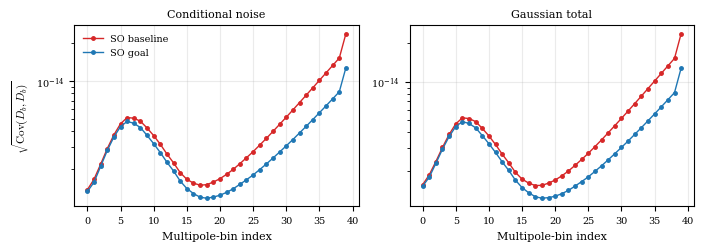

Saved: /home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures/binned_covariance_scale.jpg


In [4]:
cov_rows = []
for (case,scope),result in results.items():
    eig = np.linalg.eigvalsh(result["cov_b"])
    positive = eig[eig>0]
    correlation = result["corr_b"]
    cov_rows.append({
        "noise":CASE_LABEL[case],"covariance":SCOPE_LABEL[scope],
        "bins":len(correlation),"min_variance":np.diag(result["cov_b"]).min(),
        "max_variance":np.diag(result["cov_b"]).max(),
        "condition":positive.max()/positive.min(),
        "max_abs_offdiag_correlation":np.max(np.abs(correlation-np.eye(len(correlation))))})
covariance_table = pd.DataFrame(cov_rows)
print(covariance_table.to_string(index=False))

fig,axes = plt.subplots(1,2,figsize=(18/2.54,6.5/2.54))
for ax,scope in zip(axes,SCOPES):
    for case in CASES:
        sigma = np.sqrt(np.diag(results[(case,scope)]["cov_b"]))
        ax.plot(np.arange(len(sigma)),sigma,"o-",ms=2.5,lw=1,
                color=CASE_COLOR[case],label=CASE_LABEL[case])
    ax.set_yscale("log")
    ax.set_xlabel("Multipole-bin index")
    ax.set_title(SCOPE_LABEL[scope])
    ax.grid(alpha=0.25)
axes[0].set_ylabel(r"$\sqrt{{\rm Cov}(D_b,D_b)}$")
axes[0].legend(frameon=False)
fig.tight_layout()
covariance_path = FIG/"binned_covariance_scale.jpg"
fig.savefig(covariance_path,dpi=300)
plt.show()
print("Saved:",covariance_path)

In [5]:
LEVEL = {0.68:2.30,0.95:5.99}

def pair_cov(result,i,j):
    covariance = result["cov_theta"][np.ix_([i,j],[i,j])]
    covariance = (covariance+covariance.T)/2
    minimum = np.linalg.eigvalsh(covariance).min()
    if minimum<=0:
        covariance += np.eye(2)*(abs(minimum)+1e-14)
    return covariance

def add_ellipse(ax,mean,covariance,probability,color,filled=False,alpha=1,ls="-",lw=1.2):
    values,vectors = np.linalg.eigh(covariance)
    order = np.argsort(values)[::-1]
    values,vectors = np.maximum(values[order],0),vectors[:,order]
    angle = np.degrees(np.arctan2(vectors[1,0],vectors[0,0]))
    width,height = 2*np.sqrt(LEVEL[probability]*values)
    ax.add_patch(Ellipse(mean,width,height,angle=angle,edgecolor=color,
                         facecolor=color if filled else "none",
                         alpha=alpha,ls=ls,lw=lw))

def limits(result,i,nsigma=3.8):
    sigma = np.sqrt(result["cov_theta"][i,i])
    low = max(prior_lo[i],fid[i]-nsigma*sigma)
    high = min(prior_hi[i],fid[i]+nsigma*sigma)
    if high<=low:
        low,high = prior_lo[i],prior_hi[i]
    pad = 0.04*(high-low)
    return low-pad,high+pad

groups = {
    "profile_shape":["P0","xc","beta"],
    "mass_evolution":["alpha_m_P0","alpha_m_xc","alpha_m_beta"],
    "redshift_evolution":["alpha_z_P0","alpha_z_xc","alpha_z_beta"]}

def group_triangle(case,scope,group):
    result,selected = results[(case,scope)],groups[group]
    ids,color = [idx[name] for name in selected],CASE_COLOR[case]
    fig,axes = plt.subplots(3,3,figsize=(18/2.54,18/2.54))
    for row in range(3):
        for column in range(3):
            ax,i,j = axes[row,column],ids[column],ids[row]
            if row<column:
                ax.set_visible(False)
                continue
            if row==column:
                sigma = np.sqrt(result["cov_theta"][i,i])
                x = np.linspace(*limits(result,i),500)
                y = np.exp(-0.5*((x-fid[i])/sigma)**2)
                ax.plot(x,y,color=color,lw=1.4)
                ax.fill_between(x,0,y,color=color,alpha=0.22)
                ax.axvline(fid[i],color="black",ls=":",lw=0.9)
                ax.set_xlim(*limits(result,i))
                ax.set_ylim(0,1.08)
                ax.set_yticks([])
            else:
                covariance = pair_cov(result,i,j)
                mean = [fid[i],fid[j]]
                add_ellipse(ax,mean,covariance,0.95,color,True,0.14,lw=0.9)
                add_ellipse(ax,mean,covariance,0.68,color,True,0.32,lw=1.2)
                ax.axvline(fid[i],color="black",ls=":",lw=0.8)
                ax.axhline(fid[j],color="black",ls=":",lw=0.8)
                ax.set_xlim(*limits(result,i))
                ax.set_ylim(*limits(result,j))
            if row==2:
                ax.set_xlabel(labels[i])
            else:
                ax.set_xticklabels([])
            if column==0 and row>0:
                ax.set_ylabel(labels[j])
            elif row>column:
                ax.set_yticklabels([])
            ax.grid(alpha=0.16)
    fig.suptitle(f"{CASE_LABEL[case]}, {SCOPE_LABEL[scope]}: {group.replace('_',' ')}\n"
                 "9D prior-regularized Fisher covariance",y=0.995)
    fig.tight_layout(rect=(0,0,1,0.95))
    output = FIG/f"triangle_{case}_{scope}_{group}.jpg"
    fig.savefig(output,dpi=300)
    plt.close(fig)
    return output

triangle_paths = [group_triangle(case,scope,group)
                  for case in CASES for scope in SCOPES for group in groups]
print("Saved",len(triangle_paths),"separate triangle plots:")
print("\n".join(str(path) for path in triangle_paths))

Saved 12 separate triangle plots:
/home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures/triangle_baseline_conditional_noise_profile_shape.jpg
/home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures/triangle_baseline_conditional_noise_mass_evolution.jpg
/home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures/triangle_baseline_conditional_noise_redshift_evolution.jpg
/home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures/triangle_baseline_gaussian_total_profile_shape.jpg
/home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures/triangle_baseline_gaussian_total_mass_evolution.jpg
/home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures/triangle_baseline_gaussian_total_redshift

## Main \(P_0\)-\(\beta\) contours

Each noise implementation is kept in a separate figure. Its two panels compare covariance assumptions without overplotting. These are submatrices of the full nine-parameter prior-regularized covariance, so the other seven parameters are marginalized, not fixed.

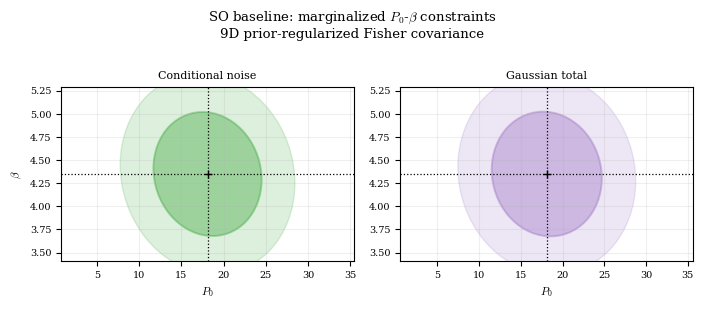

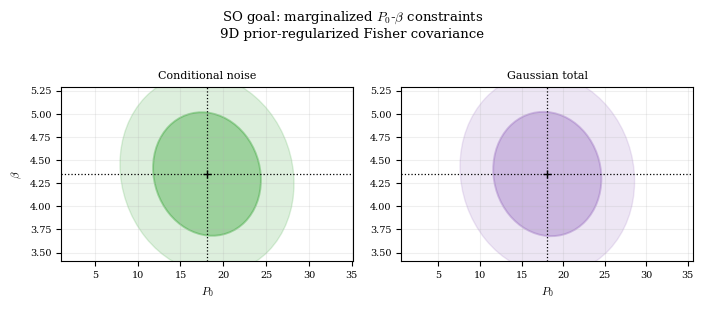

Saved:
/home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures/p0_beta_constraints_baseline.jpg
/home/cbllover/HalfDome/SBI_analysis/adrian_fisher_baseline_deproj0/2_param_fisher_analysis/notebook_figures/p0_beta_constraints_goal.jpg


In [6]:
def p0_beta(case):
    i,j = idx["P0"],idx["beta"]
    fig,axes = plt.subplots(1,2,figsize=(18/2.54,7.5/2.54))
    for ax,scope in zip(axes,SCOPES):
        result,color = results[(case,scope)],SCOPE_COLOR[scope]
        covariance,mean = pair_cov(result,i,j),[fid[i],fid[j]]
        add_ellipse(ax,mean,covariance,0.95,color,True,0.16,lw=1.0)
        add_ellipse(ax,mean,covariance,0.68,color,True,0.36,lw=1.4)
        ax.axvline(fid[i],color="black",ls=":",lw=0.9)
        ax.axhline(fid[j],color="black",ls=":",lw=0.9)
        ax.plot(fid[i],fid[j],"k+",ms=6)
        ax.set_xlim(*limits(result,i))
        ax.set_ylim(*limits(result,j))
        ax.set_xlabel(labels[i])
        ax.set_title(SCOPE_LABEL[scope])
        ax.grid(alpha=0.2)
    axes[0].set_ylabel(labels[j])
    fig.suptitle(f"{CASE_LABEL[case]}: marginalized $P_0$-$\\beta$ constraints\n"
                 "9D prior-regularized Fisher covariance",y=1.02)
    fig.tight_layout()
    output = FIG/f"p0_beta_constraints_{case}.jpg"
    fig.savefig(output,dpi=300)
    plt.show()
    return output

main_paths = [p0_beta(case) for case in CASES]
print("Saved:",*main_paths,sep="\n")

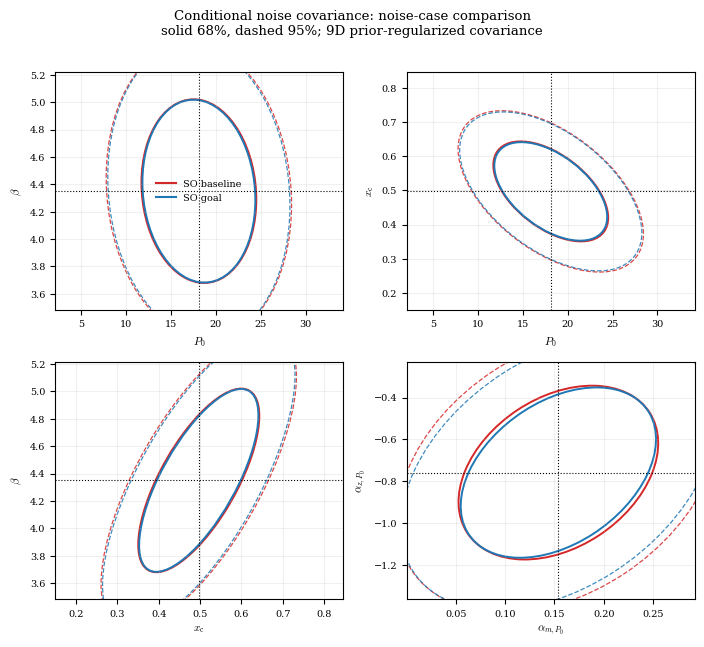

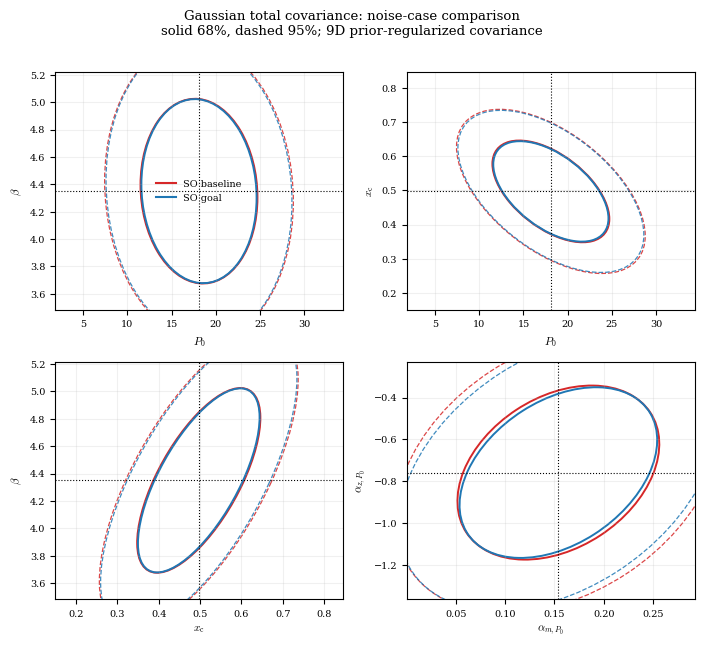

In [7]:
pairs = [("P0","beta"),("P0","xc"),("xc","beta"),
         ("alpha_m_P0","alpha_z_P0")]

def compare_noise(scope):
    fig,axes = plt.subplots(2,2,figsize=(18/2.54,16/2.54))
    for ax,(xname,yname) in zip(axes.flat,pairs):
        i,j = idx[xname],idx[yname]
        all_x,all_y = [],[]
        for case in CASES:
            result,color = results[(case,scope)],CASE_COLOR[case]
            covariance,mean = pair_cov(result,i,j),[fid[i],fid[j]]
            add_ellipse(ax,mean,covariance,0.95,color,False,0.85,"--",0.9)
            add_ellipse(ax,mean,covariance,0.68,color,False,1.0,"-",1.4)
            all_x += [fid[i]-3.8*np.sqrt(covariance[0,0]),
                      fid[i]+3.8*np.sqrt(covariance[0,0])]
            all_y += [fid[j]-3.8*np.sqrt(covariance[1,1]),
                      fid[j]+3.8*np.sqrt(covariance[1,1])]
        ax.axvline(fid[i],color="black",ls=":",lw=0.8)
        ax.axhline(fid[j],color="black",ls=":",lw=0.8)
        ax.set_xlim(max(prior_lo[i],min(all_x)),min(prior_hi[i],max(all_x)))
        ax.set_ylim(max(prior_lo[j],min(all_y)),min(prior_hi[j],max(all_y)))
        ax.set_xlabel(labels[i])
        ax.set_ylabel(labels[j])
        ax.grid(alpha=0.18)
    handles = [Line2D([0],[0],color=CASE_COLOR[c],lw=1.5,label=CASE_LABEL[c]) for c in CASES]
    axes[0,0].legend(handles=handles,frameon=False)
    fig.suptitle(f"{SCOPE_LABEL[scope]} covariance: noise-case comparison\n"
                 "solid 68%, dashed 95%; 9D prior-regularized covariance",y=1.015)
    fig.tight_layout()
    output = FIG/f"selected_constraints_noise_comparison_{scope}.jpg"
    fig.savefig(output,dpi=300)
    plt.show()
    return output

comparison_paths = [compare_noise(scope) for scope in SCOPES]

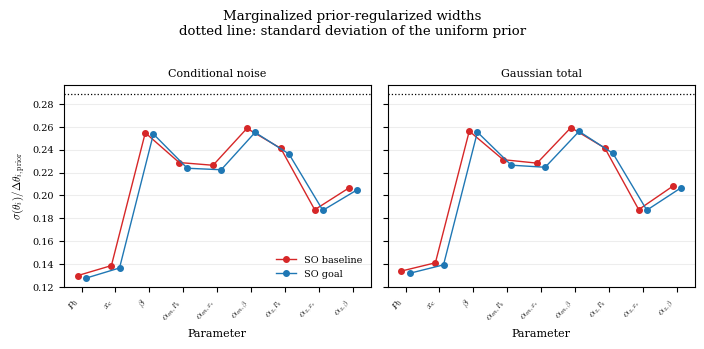

      noise        covariance    parameter  sigma_over_prior_width  estimable_fraction
SO baseline Conditional noise           P0                0.129906            0.908943
SO baseline Conditional noise           xc                0.138693            0.893197
SO baseline Conditional noise         beta                0.254691            0.635340
SO baseline Conditional noise   alpha_m_P0                0.228723            0.576459
SO baseline Conditional noise   alpha_m_xc                0.226332            0.724674
SO baseline Conditional noise alpha_m_beta                0.258559            0.368852
SO baseline Conditional noise   alpha_z_P0                0.241064            0.513176
SO baseline Conditional noise   alpha_z_xc                0.187493            0.631708
SO baseline Conditional noise alpha_z_beta                0.206333            0.747651
    SO goal Conditional noise           P0                0.127656            0.907979
    SO goal Conditional noise           xc 

In [8]:
fig,axes = plt.subplots(1,2,figsize=(18/2.54,8.5/2.54),sharey=True)
x = np.arange(9)
sigma_rows = []
for ax,scope in zip(axes,SCOPES):
    for case,offset in zip(CASES,(-0.12,0.12)):
        result = results[(case,scope)]
        sigma = np.sqrt(np.diag(result["cov_q"]))
        ax.plot(x+offset,sigma,"o-",ms=4,lw=1,color=CASE_COLOR[case],label=CASE_LABEL[case])
        sigma_rows += [{"noise":CASE_LABEL[case],"covariance":SCOPE_LABEL[scope],
                        "parameter":name,"sigma_over_prior_width":value,
                        "estimable_fraction":result["estimable"][idx[name]]}
                       for name,value in zip(names,sigma)]
    ax.axhline(1/np.sqrt(12),color="black",ls=":",lw=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(labels,rotation=55,ha="right")
    ax.set_title(SCOPE_LABEL[scope])
    ax.set_xlabel("Parameter")
    ax.grid(axis="y",alpha=0.22)
axes[0].set_ylabel(r"$\sigma(\theta_i)/\Delta\theta_{i,{\rm prior}}$")
axes[0].legend(frameon=False)
fig.suptitle("Marginalized prior-regularized widths\n"
             "dotted line: standard deviation of the uniform prior",y=1.02)
fig.tight_layout()
sigma_path = FIG/"marginalized_sigma_over_prior_width.jpg"
fig.savefig(sigma_path,dpi=300)
plt.show()
sigma_table = pd.DataFrame(sigma_rows)
sigma_table.to_csv(FIG/"marginalized_sigma_over_prior_width.csv",index=False)
print(sigma_table.to_string(index=False))

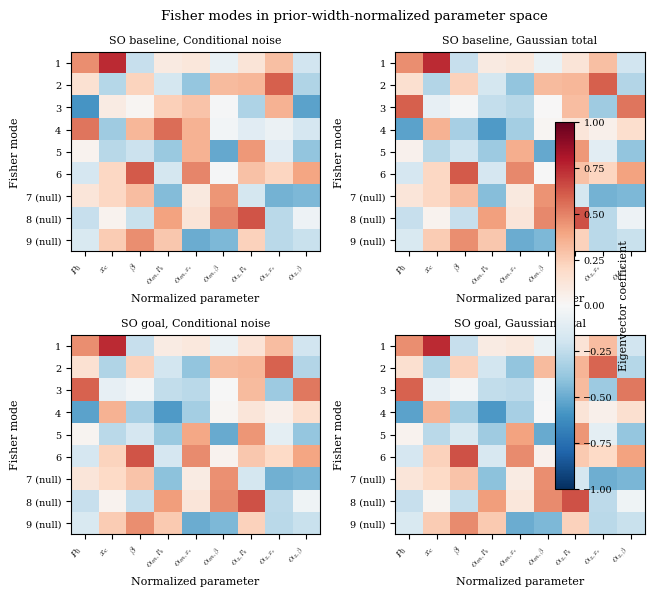

Null modes:
      noise        covariance  mode  identified  eigenvalue                                            dominant_parameters
SO baseline Conditional noise     7       False    0.051822 alpha_z_xc (-0.47), alpha_z_beta (-0.45), alpha_m_beta (+0.44)
SO baseline Conditional noise     8       False    0.004469   alpha_z_P0 (+0.63), alpha_m_beta (+0.49), alpha_m_P0 (+0.40)
SO baseline Conditional noise     9       False    0.000450         alpha_m_xc (-0.50), beta (+0.47), alpha_m_beta (-0.45)
SO baseline    Gaussian total     7       False    0.048477 alpha_z_xc (-0.47), alpha_z_beta (-0.45), alpha_m_beta (+0.45)
SO baseline    Gaussian total     8       False    0.004115   alpha_z_P0 (+0.63), alpha_m_beta (+0.48), alpha_m_P0 (+0.41)
SO baseline    Gaussian total     9       False    0.000424         alpha_m_xc (-0.50), beta (+0.47), alpha_m_beta (-0.45)
    SO goal Conditional noise     7       False    0.073211 alpha_z_xc (-0.48), alpha_m_beta (+0.46), alpha_z_beta (-0.46)
    

In [9]:
fig,axes = plt.subplots(2,2,figsize=(18/2.54,15.5/2.54))
mode_rows = []
for ax,((case,scope),result) in zip(axes.flat,results.items()):
    values,vectors = np.linalg.eigh(result["fisher_q"])
    order = np.argsort(values)[::-1]
    values,vectors = values[order],vectors[:,order]
    keep = np.arange(len(values)) < int(result["identified"].sum())
    image = ax.imshow(vectors.T,cmap="RdBu_r",vmin=-1,vmax=1,aspect="auto")
    ax.set_xticks(np.arange(9))
    ax.set_xticklabels(labels,rotation=55,ha="right")
    ax.set_yticks(np.arange(9))
    ax.set_yticklabels([f"{k+1}{'' if keep[k] else ' (null)'}" for k in range(9)])
    ax.set_title(f"{CASE_LABEL[case]}, {SCOPE_LABEL[scope]}")
    ax.set_xlabel("Normalized parameter")
    ax.set_ylabel("Fisher mode")
    for k,(value,vector,identified) in enumerate(zip(values,vectors.T,keep)):
        dominant = np.argsort(np.abs(vector))[::-1][:3]
        mode_rows.append({
            "noise":CASE_LABEL[case],"covariance":SCOPE_LABEL[scope],
            "mode":k+1,"identified":bool(identified),"eigenvalue":value,
            "dominant_parameters":", ".join(f"{names[q]} ({vector[q]:+.2f})" for q in dominant)})
fig.colorbar(image,ax=axes.ravel().tolist(),shrink=0.78,label="Eigenvector coefficient")
fig.suptitle("Fisher modes in prior-width-normalized parameter space")
fig.subplots_adjust(left=0.10,right=0.91,bottom=0.12,top=0.91,wspace=0.30,hspace=0.42)
mode_path = FIG/"fisher_eigenmodes.jpg"
fig.savefig(mode_path,dpi=300)
plt.show()
mode_table = pd.DataFrame(mode_rows)
mode_table.to_csv(FIG/"fisher_eigenmodes.csv",index=False)
print("Null modes:")
print(mode_table[~mode_table["identified"]].to_string(index=False))

## Reading the outputs

1. Start with the two p0_beta_constraints noise figures. They are the clearest marginalized \(P_0\)-\(\beta\) constraints.
2. Use the 12 separate triangle JPGs for within-case parameter groups. This avoids hiding contours beneath four overlaid cases.
3. Compare baseline and goal only within one covariance prescription using the selected_constraints_noise_comparison figures.
4. Check marginalized_sigma_over_prior_width.jpg. A width near \(1/\sqrt{12}\) remains close to the input uniform prior.
5. Check fisher_eigenmodes.jpg before quoting constraints. Three null modes mean the data alone cannot identify all nine simultaneous combinations.
6. Conditional-noise and Gaussian-total answer different forecasting questions. Neither includes connected non-Gaussian tSZ covariance or exact mask mode coupling.

## Nine-parameter Fisher versus Battaglia12 SBI

This section loads the saved N=523,788 MAF posterior and conditions it directly on the Fisher Battaglia12 fiducial mean D_ell after applying the run's saved asinh(x/s) transformation. Samples are cached together with their transformed-observation contract.


In [10]:
from getdist import MCSamples, plots
import hashlib
import pickle
import warnings

# Saved full-dataset MAF posterior. posterior.pkl contains the trained density
# estimator plus the bounded training prior; no retraining is performed here.
SBI_RUN = ROOT.parents[1] / "convergence_tests" / "N523788"
SBI_POSTERIOR = SBI_RUN / "posterior.pkl"
SBI_ESTIMATOR_STATE = SBI_RUN / "density_estimator_state_dict.pt"
SBI_METADATA = SBI_RUN / "run_metadata.json"
SBI_TRANSFORM = SBI_RUN / "x_transform.npz"

# Fisher Asimov observation at the Battaglia12 fiducial, using the same 40
# binned D_ell components as the NPE.
BATTAGLIA_D_ELL = (
    ROOT.parent / "analysis" / "fiducial_battaglia12_dell.npy"
)

NUM_BATTAGLIA_SAMPLES = 20_000
BATTAGLIA_SAMPLE_BATCH = 1_000
REGENERATE_BATTAGLIA_SAMPLES = False
BATTAGLIA_CACHE = ROOT / "battaglia12_sbi_posterior_N523788_direct.npz"
BATTAGLIA_PARTIAL = ROOT / "battaglia12_sbi_posterior_N523788_direct_partial.npz"

for required in (
    SBI_POSTERIOR,
    SBI_ESTIMATOR_STATE,
    SBI_METADATA,
    SBI_TRANSFORM,
    BATTAGLIA_D_ELL,
):
    if not required.exists():
        raise FileNotFoundError(f"Missing Battaglia12 NPE input: {required}")

metadata = json.loads(SBI_METADATA.read_text())
SBI_N_TRAIN = int(metadata["n_train"])
if SBI_N_TRAIN != 523_788:
    raise ValueError(f"Expected N=523,788, found N={SBI_N_TRAIN:,}.")
if metadata.get("density_estimator") != "maf":
    raise ValueError(f"Expected MAF, found {metadata.get('density_estimator')!r}.")
if metadata.get("x_rescale_mode") != "asinh":
    raise ValueError(
        f"Expected asinh(x/s), found {metadata.get('x_rescale_mode')!r}."
    )

with np.load(SBI_TRANSFORM, allow_pickle=True) as z:
    transform_mode = str(np.asarray(z["mode"]).reshape(()).item())
    transform_scale = np.asarray(z["scale"], dtype=np.float32)
if transform_mode != "asinh":
    raise ValueError(f"Expected saved asinh transform, found {transform_mode!r}.")
if transform_scale.shape != (len(names),) and transform_scale.shape != (40,):
    raise ValueError(f"Unexpected x-transform scale shape {transform_scale.shape}.")

battaglia_dell = np.asarray(np.load(BATTAGLIA_D_ELL), dtype=np.float32)
if battaglia_dell.shape != transform_scale.shape:
    raise ValueError(
        f"Battaglia12 D_ell shape {battaglia_dell.shape} does not match "
        f"the NPE context shape {transform_scale.shape}."
    )
if not np.all(np.isfinite(battaglia_dell)):
    raise ValueError("Battaglia12 D_ell contains non-finite values.")

SBI_OBS_TRANSFORMED = np.arcsinh(
    battaglia_dell / transform_scale
).astype(np.float32)
SBI_TRUTH = np.asarray(fid, dtype=float)
SBI_OBS_SOURCE = "Battaglia12 Fisher fiducial mean D_ell"
observation_hash = hashlib.sha256(
    np.ascontiguousarray(SBI_OBS_TRANSFORMED).view(np.uint8)
).hexdigest()

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

estimator_hash = sha256_file(SBI_ESTIMATOR_STATE)

def load_sample_cache(path):
    with np.load(path, allow_pickle=True) as z:
        samples = np.asarray(z["samples"], dtype=float)
        cached_x = np.asarray(z["x_transformed"], dtype=np.float32)
        cached_truth = np.asarray(z["theta_true"], dtype=float)
        cached_names = [str(value) for value in z["param_names"]]
        cached_run_name = str(np.asarray(z["npe_run_name"]).reshape(()).item())
        cached_hash = str(np.asarray(z["observation_hash"]).reshape(()).item())
        cached_estimator_hash = str(
            np.asarray(z["estimator_hash"]).reshape(()).item()
        )
    if cached_names != names:
        raise ValueError(f"Cached parameter order {cached_names} != {names}.")
    if not np.array_equal(cached_x, SBI_OBS_TRANSFORMED):
        raise ValueError(f"Cached samples use a different observation: {path}")
    if not np.array_equal(cached_truth, SBI_TRUTH):
        raise ValueError(f"Cached samples use a different truth: {path}")
    if cached_run_name != SBI_RUN.name:
        raise ValueError(f"Cached samples use a different NPE run: {path}")
    if cached_estimator_hash != estimator_hash:
        raise ValueError(f"Cached samples use a different estimator: {path}")
    if cached_hash != observation_hash:
        raise ValueError(f"Cached observation hash is inconsistent: {path}")
    return samples

def save_sample_cache(path, samples):
    np.savez_compressed(
        path,
        samples=np.asarray(samples, dtype=np.float32),
        x_transformed=SBI_OBS_TRANSFORMED,
        x_binned_dell=battaglia_dell,
        theta_true=SBI_TRUTH,
        param_names=np.asarray(names),
        npe_run_name=np.asarray(SBI_RUN.name),
        observation_source=np.asarray(SBI_OBS_SOURCE),
        observation_hash=np.asarray(observation_hash),
        estimator_hash=np.asarray(estimator_hash),
        sampling_method=np.asarray("DirectPosterior rejection"),
    )

def sample_direct_posterior(posterior, x_obs, count):
    import torch

    x_t = torch.as_tensor(x_obs, dtype=torch.float32)
    try:
        samples = posterior.sample(
            (int(count),),
            x=x_t,
            show_progress_bars=True,
        )
    except TypeError:
        posterior_x = posterior.set_default_x(x_t)
        if posterior_x is None:
            posterior_x = posterior
        try:
            samples = posterior_x.sample(
                (int(count),),
                show_progress_bars=True,
            )
        except TypeError:
            samples = posterior_x.sample((int(count),))
    if torch.is_tensor(samples):
        samples = samples.detach().cpu().numpy()
    samples = np.asarray(samples, dtype=float)
    if samples.ndim > 2:
        samples = samples.reshape(-1, samples.shape[-1])
    if samples.ndim != 2 or samples.shape[1] != len(names):
        raise ValueError(f"Posterior returned invalid shape {samples.shape}.")
    return samples

if BATTAGLIA_CACHE.exists() and not REGENERATE_BATTAGLIA_SAMPLES:
    sbi_samples = load_sample_cache(BATTAGLIA_CACHE)
    print("Reusing Battaglia12 posterior cache:", BATTAGLIA_CACHE)
else:
    if REGENERATE_BATTAGLIA_SAMPLES:
        BATTAGLIA_CACHE.unlink(missing_ok=True)
        BATTAGLIA_PARTIAL.unlink(missing_ok=True)

    if BATTAGLIA_PARTIAL.exists():
        sbi_samples = load_sample_cache(BATTAGLIA_PARTIAL)
        print(
            "Resuming Battaglia12 posterior:",
            len(sbi_samples),
            "/",
            NUM_BATTAGLIA_SAMPLES,
        )
    else:
        sbi_samples = np.empty((0, len(names)), dtype=float)

    with SBI_POSTERIOR.open("rb") as handle:
        posterior = pickle.load(handle)

    while len(sbi_samples) < NUM_BATTAGLIA_SAMPLES:
        requested = min(
            BATTAGLIA_SAMPLE_BATCH,
            NUM_BATTAGLIA_SAMPLES - len(sbi_samples),
        )
        new_samples = sample_direct_posterior(
            posterior,
            SBI_OBS_TRANSFORMED,
            requested,
        )
        sbi_samples = np.concatenate((sbi_samples, new_samples), axis=0)
        save_sample_cache(BATTAGLIA_PARTIAL, sbi_samples)
        print(
            "Battaglia12 posterior checkpoint:",
            len(sbi_samples),
            "/",
            NUM_BATTAGLIA_SAMPLES,
        )

    sbi_samples = sbi_samples[:NUM_BATTAGLIA_SAMPLES]
    save_sample_cache(BATTAGLIA_CACHE, sbi_samples)
    BATTAGLIA_PARTIAL.unlink(missing_ok=True)
    print("Saved Battaglia12 posterior:", BATTAGLIA_CACHE)

if not np.all(np.isfinite(sbi_samples)):
    raise ValueError("Battaglia12 SBI samples contain non-finite values.")
inside_prior = np.all(
    (sbi_samples >= prior_lo.reshape(1, -1))
    & (sbi_samples <= prior_hi.reshape(1, -1)),
    axis=1,
)
if not np.all(inside_prior):
    raise ValueError(
        f"Only {inside_prior.mean():.3%} of direct-posterior samples "
        "are inside the training prior."
    )

lag1 = np.array([
    np.corrcoef(sbi_samples[:-1, j], sbi_samples[1:, j])[0, 1]
    for j in range(sbi_samples.shape[1])
])
max_lag1 = float(np.nanmax(np.abs(lag1)))
SBI_CHAIN_VALID = bool(max_lag1 < 0.1)
if not SBI_CHAIN_VALID:
    raise RuntimeError(
        "Battaglia12 direct samples failed the independence diagnostic: "
        f"max |lag-1|={max_lag1:.4f}."
    )
SBI_SAME_FIDUCIAL_AS_FISHER = True

print("NPE run:", SBI_RUN)
print("density estimator:", metadata["density_estimator"])
print("N_train:", f"{SBI_N_TRAIN:,}")
print("observation:", SBI_OBS_SOURCE)
print("observation hash:", observation_hash)
print("density-estimator hash:", estimator_hash)
print("transformed observation range:", (
    float(SBI_OBS_TRANSFORMED.min()),
    float(SBI_OBS_TRANSFORMED.max()),
))
print("posterior samples:", sbi_samples.shape)
print("fraction inside prior:", f"{inside_prior.mean():.3%}")
print("lag-1 by parameter:", dict(zip(names, lag1.round(4))))


2026-09-01 17:29:15.778559: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-01 17:29:16.608766: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'Flow' object has no attribute 'condition_shape'

In [ ]:
FISHER_CASE = ("baseline", "gaussian_total")
MATCH_UNIFORM_PRIOR_SUPPORT = True
N_FISHER_SAMPLES = 200_000
rng = np.random.default_rng(271828)

fisher_cov = np.asarray(results[FISHER_CASE]["cov_theta"], dtype=float)
fisher_cov = (fisher_cov + fisher_cov.T) / 2
values, vectors = np.linalg.eigh(fisher_cov)
floor = max(np.max(np.abs(values)) * 1e-12, 1e-18)
fisher_cov = (vectors * np.maximum(values, floor)) @ vectors.T

def draw_fisher(count, match_prior_support=True):
    accepted = []
    total = 0
    while total < count:
        batch = rng.multivariate_normal(
            fid, fisher_cov, size=max(20_000, 2 * (count - total))
        )
        if match_prior_support:
            batch = batch[np.all(
                (batch >= prior_lo.reshape(1, -1))
                & (batch <= prior_hi.reshape(1, -1)),
                axis=1,
            )]
        accepted.append(batch)
        total += len(batch)
    return np.concatenate(accepted)[:count]

fisher_samples_9d = draw_fisher(
    N_FISHER_SAMPLES, MATCH_UNIFORM_PRIOR_SUPPORT
)

rows = []
for method, chain in [
    ("Fisher + prior support", fisher_samples_9d),
    (f"SBI MAF N={SBI_N_TRAIN:,}", sbi_samples),
]:
    mean = chain.mean(axis=0)
    std = chain.std(axis=0, ddof=1)
    for i, name in enumerate(names):
        rows.append({
            "method": method,
            "conditioning_point": "Battaglia12",
            "parameter": name,
            "truth": fid[i],
            "mean": mean[i],
            "std": std[i],
            "mean_minus_truth_over_std": (mean[i] - fid[i]) / std[i],
            "std_over_prior_width": std[i] / prior_width[i],
        })

fisher_sbi_9d_summary = pd.DataFrame(rows)
summary_9d_path = (
    FIG / "fisher_baseline_vs_sbi_N523788_battaglia12_9param_summary.csv"
)
fisher_sbi_9d_summary.to_csv(summary_9d_path, index=False)
display(fisher_sbi_9d_summary)


In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch

gd_labels = [LABEL.get(name, name).strip("$") for name in names]
gd_ranges = {
    name: [float(lo), float(hi)]
    for name, lo, hi in zip(names, prior_lo, prior_hi)
}
fisher_label = "Fisher at Battaglia12: baseline Gaussian total"
sbi_label = rf"SBI MAF at Battaglia12: $N_{{\rm train}}={SBI_N_TRAIN:,}$"

gd_sbi = MCSamples(
    samples=sbi_samples,
    names=names,
    labels=gd_labels,
    label=sbi_label,
    ranges=gd_ranges,
)
gd_sbi.updateSettings({
    "smooth_scale_1D": 0.3,
    "smooth_scale_2D": 0.3,
    "fine_bins": 2048,
    "fine_bins_2D": 1024,
})

g = plots.get_subplot_plotter(width_inch=18.0 / 2.54)
g.settings.axes_fontsize = 5.5
g.settings.lab_fontsize = 7
g.settings.legend_fontsize = 7
g.settings.alpha_filled_add = 0.45
g.settings.linewidth = 1.0
g.settings.num_plot_contours = 2
g.settings.figure_legend_frame = False
g.settings.scaling = False

SBI_COLOR = "#C14953"
FISHER_COLOR = "#355C7D"

# Draw GetDist once. A second triangle_plot call clears the first plot in the
# GetDist version used for this analysis.
g.triangle_plot(
    [gd_sbi],
    params=names,
    filled=True,
    legend_labels=[sbi_label],
    contour_colors=[SBI_COLOR],
    line_args=[{"color": SBI_COLOR, "lw": 1.3, "ls": "-"}],
    diag1d_kwargs={"linestyle": "-", "linewidth": 1.2},
    markers=SBI_TRUTH,
    marker_args={"color": "black", "lw": 0.8, "ls": ":"},
)

figure = plt.gcf()
for legend in list(figure.legends):
    legend.remove()

fisher_sigma = np.sqrt(np.clip(np.diag(fisher_cov), 0.0, None))
sbi_q_low, sbi_q_high = np.quantile(sbi_samples, [0.001, 0.999], axis=0)
plot_limits = []
for i in range(len(names)):
    lower = min(sbi_q_low[i], SBI_TRUTH[i],
                fid[i] - 3.5 * fisher_sigma[i], fid[i])
    upper = max(sbi_q_high[i], SBI_TRUTH[i],
                fid[i] + 3.5 * fisher_sigma[i], fid[i])
    span = max(upper - lower, 1e-12)
    lower = max(prior_lo[i], lower - 0.04 * span)
    upper = min(prior_hi[i], upper + 0.04 * span)
    plot_limits.append((lower, upper))

# Delta chi^2 = 2.30 and 5.991 enclose 68.3% and 95.0% in two dimensions.
fisher_levels = ((5.991, "--", 0.9), (2.30, "-", 1.2))

for row in range(len(names)):
    for column in range(row + 1):
        ax = g.subplots[row, column]
        if ax is None:
            continue
        ax.set_xlim(*plot_limits[column])

        if row == column:
            sigma = fisher_sigma[row]
            if sigma > 0.0:
                x_grid = np.linspace(*plot_limits[row], 600)
                density = np.exp(-0.5 * ((x_grid - fid[row]) / sigma) ** 2)
                y0, y1 = ax.get_ylim()
                amplitude = 0.92 * max(y1 - y0, 1e-12)
                ax.plot(
                    x_grid,
                    y0 + amplitude * density,
                    color=FISHER_COLOR,
                    lw=1.1,
                    ls="--",
                    zorder=30,
                )
            continue

        ax.set_ylim(*plot_limits[row])
        pair = np.asarray(
            fisher_cov[np.ix_([column, row], [column, row])],
            dtype=float,
        )
        pair = 0.5 * (pair + pair.T)
        eigenvalues, eigenvectors = np.linalg.eigh(pair)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = np.clip(eigenvalues[order], 0.0, None)
        eigenvectors = eigenvectors[:, order]
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

        for delta_chi2, linestyle, linewidth in fisher_levels:
            width, height = 2.0 * np.sqrt(delta_chi2 * eigenvalues)
            ax.add_patch(Ellipse(
                xy=(fid[column], fid[row]),
                width=width,
                height=height,
                angle=angle,
                facecolor="none",
                edgecolor=FISHER_COLOR,
                linestyle=linestyle,
                linewidth=linewidth,
                zorder=30,
            ))

legend_handles = [
    Patch(
        facecolor=SBI_COLOR,
        edgecolor=SBI_COLOR,
        alpha=0.35,
        label=sbi_label,
    ),
    Line2D(
        [0],
        [0],
        color=FISHER_COLOR,
        lw=1.2,
        label=fisher_label + " (68/95%)",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        lw=0.8,
        ls=":",
        label="Battaglia12 truth",
    ),
]
figure.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    frameon=False,
    fontsize=7,
)

figure.subplots_adjust(top=0.94)

corner_9d_path = (
    FIG / "fisher_baseline_vs_sbi_N523788_battaglia12_9param.jpg"
)
plt.savefig(corner_9d_path, dpi=350)
plt.show()
print("Saved:", corner_9d_path)
print("Saved:", summary_9d_path)


### Interpretation

Black dotted markers are Battaglia12. Filled red contours are direct prior-restricted samples from the saved N=523,788 MAF conditioned on the same Battaglia12 fiducial mean D_ell used by the Fisher forecast. Blue curves are the prior-regularized Fisher Gaussian; solid and dashed ellipses show its 68% and 95% regions.
